# Analyse de la couverture médiatique du Bénin — 2025
**Hackathon iSHEERO × DataCamp 2026 — Bénin Insights Challenge**

---

## 1. Introduction

Ce notebook analyse la couverture médiatique internationale du Bénin sur l'ensemble de l'année 2025 à partir de la base GDELT (*Global Database of Events, Language and Tone*).

**Question principale :** comment les médias mondiaux ont-ils couvert le Bénin en 2025, et quels facteurs déterminent le ton de cette couverture ?

**Pipeline :**
1. Pipeline de données (BigQuery → nettoyage → enrichissement)
2. Chargement des données préparées (`benin_enrichi.csv`)
3. Analyse exploratoire — 5 visualisations
4. Modèle de classification du ton médiatique (Random Forest)

**Données :** 10 722 événements médiatiques · 1er janvier → 31 décembre 2025 · filtre `ActionGeo_CountryCode = 'BN'`

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import joblib
import os
import warnings
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

ROOT = Path('../')
Path(ROOT / 'notebooks/outputs').mkdir(exist_ok=True)

---

## 2. Pipeline de données

Le pipeline extrait les données brutes de BigQuery, les nettoie et les enrichit.
Si `data/processed/benin_enrichi.csv` est déjà disponible, passer directement à la section 3.

**Étapes :**
1. Sélection des 25 colonnes utiles GDELT
2. Correction des types (dates, numériques)
3. Nettoyage (doublons, dates manquantes)
4. Enrichissement : colonnes temporelles, `ton_categorie`, `zone_benin`, `quadclass_label`
5. Assertions qualité + sauvegarde CSV / Parquet

> **Note :** l'extraction BigQuery nécessite un accès configuré.
> Les données brutes sont disponibles dans `data/raw/benin_raw.csv`.

In [15]:
RAW_PATH = ROOT / 'data/raw/benin_raw.csv'
PROC_DIR = ROOT / 'data/processed'

if not RAW_PATH.exists():
    print(f'Données brutes introuvables : {RAW_PATH}')
    print('Section ignorée — chargement direct de benin_enrichi.csv en section 3.')
else:
    df_raw = pd.read_csv(RAW_PATH, low_memory=False)
    print(f'{len(df_raw):,} lignes brutes · {df_raw.shape[1]} colonnes')

    # 1. Sélection des colonnes
    COLONNES = [
        'GLOBALEVENTID','SQLDATE','MONTHYEAR','YEAR','FractionDate','IsRootEvent',
        'ActionGeo_CountryCode','ActionGeo_FullName','ActionGeo_ADM1Code',
        'ActionGeo_Lat','ActionGeo_Long','Actor1Geo_CountryCode','Actor2Geo_CountryCode',
        'Actor1CountryCode','Actor2CountryCode','Actor1Name','Actor2Name',
        'Actor1Type1Code','Actor2Type1Code','Actor1KnownGroupCode','Actor2KnownGroupCode',
        'EventRootCode','EventBaseCode','EventCode','QuadClass',
        'GoldsteinScale','NumMentions','NumSources','NumArticles','AvgTone','SOURCEURL'
    ]
    presentes = [c for c in COLONNES if c in df_raw.columns]
    df_pipe = df_raw[presentes].copy()
    print(f'{len(presentes)} colonnes conservées')

    # 2. Correction des types
    df_pipe['SQLDATE'] = pd.to_datetime(
        df_pipe['SQLDATE'].astype(str), format='%Y%m%d', errors='coerce'
    )
    for col in ['FractionDate','GoldsteinScale','AvgTone','ActionGeo_Lat','ActionGeo_Long',
                'NumMentions','NumSources','NumArticles','IsRootEvent','QuadClass']:
        if col in df_pipe.columns:
            df_pipe[col] = pd.to_numeric(df_pipe[col], errors='coerce')

    # 3. Nettoyage
    n0 = len(df_pipe)
    df_pipe = df_pipe.drop_duplicates(subset=['GLOBALEVENTID']).dropna(subset=['SQLDATE'])
    print(f'{n0 - len(df_pipe):,} lignes supprimées → {len(df_pipe):,} restantes')

    # 4. Enrichissement
    df_pipe['mois']         = df_pipe['SQLDATE'].dt.month
    df_pipe['trimestre']    = df_pipe['SQLDATE'].dt.quarter
    df_pipe['annee']        = df_pipe['SQLDATE'].dt.year
    df_pipe['mois_annee']   = df_pipe['SQLDATE'].dt.to_period('M').astype(str)
    df_pipe['jour_semaine'] = df_pipe['SQLDATE'].dt.dayofweek

    def cat_ton(t):
        if pd.isna(t): return 'inconnu'
        if t > 3: return 'tres_positif'
        if t > 1: return 'positif'
        if t < -3: return 'tres_negatif'
        if t < -1: return 'negatif'
        return 'neutre'
    df_pipe['ton_categorie'] = df_pipe['AvgTone'].apply(cat_ton)

    quad_map = {1:'cooperation_verbale', 2:'cooperation_materielle',
                3:'conflit_verbal', 4:'conflit_materiel'}
    df_pipe['quadclass_label'] = df_pipe['QuadClass'].map(quad_map)

    NORD = ['banikoara','gogounou','kandi','karimama','malanville','segbana',
            'natitingou','djougou','parakou','bembereke','nikki','tchaourou',
            'tanguieta','alibori','atacora','borgou','donga']
    CENTRE = ['abomey','bohicon','cove','djidja','zagnanado','zogbodomey',
              'bante','dassa','glazoue','ouesse','savalou','save','zou','collines']
    def zone(nom):
        if pd.isna(nom): return 'inconnu'
        n = str(nom).lower()
        if any(v in n for v in NORD): return 'nord'
        if any(v in n for v in CENTRE): return 'centre'
        return 'sud'
    df_pipe['zone_benin'] = df_pipe['ActionGeo_FullName'].apply(zone)

    # 5. Assertions qualité
    assert len(df_pipe) > 100
    assert df_pipe['GLOBALEVENTID'].duplicated().sum() == 0
    assert df_pipe['SQLDATE'].isna().sum() == 0
    print('Assertions qualité : OK')

    # Sauvegarde
    os.makedirs(PROC_DIR, exist_ok=True)
    df_pipe.to_csv(PROC_DIR / 'benin_enrichi.csv', index=False)
    csv_ko = (PROC_DIR / 'benin_enrichi.csv').stat().st_size // 1024
    print(f'benin_enrichi.csv : {csv_ko} Ko')
    try:
        df_pipe.to_parquet(PROC_DIR / 'benin_enrichi.parquet', index=False)
        pq_ko = (PROC_DIR / 'benin_enrichi.parquet').stat().st_size // 1024
        print(f'benin_enrichi.parquet : {pq_ko} Ko')
    except ImportError:
        print('benin_enrichi.parquet : ignoré (pyarrow non installé)')

10,722 lignes brutes · 31 colonnes
31 colonnes conservées
0 lignes supprimées → 10,722 restantes
Assertions qualité : OK
benin_enrichi.csv : 3008 Ko
benin_enrichi.parquet : ignoré (pyarrow non installé)


---

## 3. Chargement des données

In [16]:
df = pd.read_csv(ROOT / 'data/processed/benin_enrichi.csv', parse_dates=['SQLDATE'])

print(f'Dimensions     : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print(f'Période        : {df["SQLDATE"].min().date()} → {df["SQLDATE"].max().date()}')
print(f'Jours couverts : {df["SQLDATE"].dt.date.nunique()} / 365')
df.head(3)

Dimensions     : 10,722 lignes × 39 colonnes
Période        : 2025-01-01 → 2025-12-31
Jours couverts : 349 / 365


,GLOBALEVENTID,SQLDATE,MONTHYEAR,YEAR,FractionDate,IsRootEvent,ActionGeo_CountryCode,ActionGeo_FullName,ActionGeo_ADM1Code,ActionGeo_Lat,...,AvgTone,SOURCEURL,mois,trimestre,annee,mois_annee,jour_semaine,ton_categorie,quadclass_label,zone_benin
0,1281664740,2025-12-31,202512,2025,2025.989,1,BN,Benin,BN,9.5,...,-1.09589,https://www.rewmi.com/koulibaly-la-rdc-va-fair...,12,4,2025,2025-12,2,negatif,cooperation_verbale,sud
1,1281664663,2025-12-31,202512,2025,2025.989,1,BN,Benin,BN,9.5,...,-1.09589,https://www.rewmi.com/koulibaly-la-rdc-va-fair...,12,4,2025,2025-12,2,negatif,cooperation_verbale,sud
2,1281698938,2025-12-31,202512,2025,2025.989,1,BN,Benin,BN,9.5,...,-9.76801,https://www.firstpost.com/world/2025-year-ende...,12,4,2025,2025-12,2,tres_negatif,conflit_materiel,sud


---

## 4. Préparation

In [17]:
# Variable cible : ton positif (1) ou négatif (0)
df['ton_binaire'] = (df['AvgTone'] > 0).astype(int)

# Vérification des colonnes clés
cles = ['AvgTone', 'GoldsteinScale', 'QuadClass', 'zone_benin', 'mois',
        'mois_annee', 'quadclass_label', 'NumMentions', 'NumArticles']
manquants = df[cles].isnull().sum()
print('Valeurs manquantes (colonnes utilisées) :')
print(manquants[manquants > 0] if manquants.sum() > 0 else '  Aucune')

print(f'\nDistribution ton_binaire :')
print(df['ton_binaire'].value_counts().rename({0:'Négatif (0)', 1:'Positif (1)'}).to_string())
print(f'Ratio positif : {df["ton_binaire"].mean():.1%}')

Valeurs manquantes (colonnes utilisées) :
  Aucune

Distribution ton_binaire :
ton_binaire
Négatif (0)    6442
Positif (1)    4280
Ratio positif : 39.9%


---

## 5. Analyse exploratoire

### 5.1 Ton médiatique mensuel

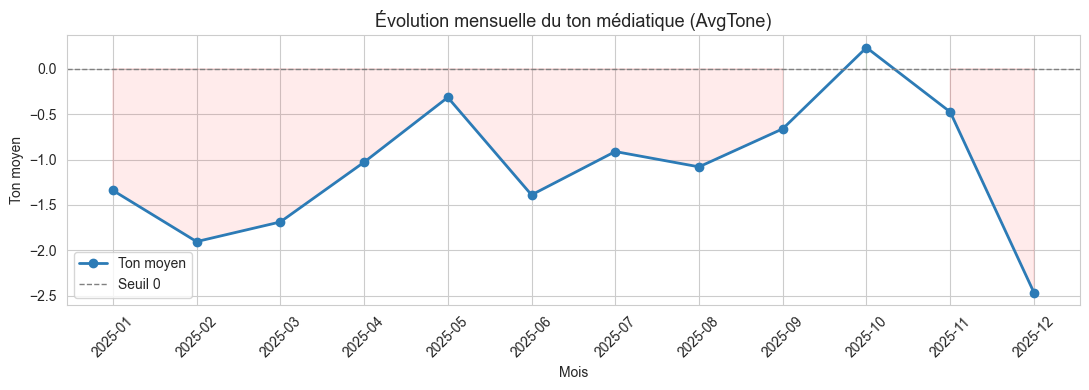

In [18]:
tone_m = (
    df.groupby('mois_annee')['AvgTone']
    .mean()
    .reset_index()
    .sort_values('mois_annee')
)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(tone_m['mois_annee'], tone_m['AvgTone'],
        marker='o', color='#2c7bb6', linewidth=2, label='Ton moyen')
ax.axhline(0, color='gray', linestyle='--', linewidth=1, label='Seuil 0')
ax.fill_between(tone_m['mois_annee'], tone_m['AvgTone'], 0,
                where=(tone_m['AvgTone'] < 0), alpha=0.08, color='red')
ax.fill_between(tone_m['mois_annee'], tone_m['AvgTone'], 0,
                where=(tone_m['AvgTone'] > 0), alpha=0.08, color='green')
ax.set_title('Évolution mensuelle du ton médiatique (AvgTone)', fontsize=13)
ax.set_xlabel('Mois')
ax.set_ylabel('Ton moyen')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig(ROOT / 'notebooks/outputs/final_viz1_tone.png', dpi=120)
plt.show()

**Ce qu'on observe :**

- Le ton médiatique est négatif sur 11 des 12 mois de 2025 — octobre est le seul mois légèrement positif (+0,23).
- Décembre 2025 est le mois le plus négatif (−2,46), tiré vers le bas par un pic médiatique exceptionnel.
- Il n'y a pas de tendance progressive d'amélioration ou de dégradation : les variations sont irrégulières.
- La couverture médiatique du Bénin est structurellement négative sur toute l'année 2025.

### 5.2 Score Goldstein mensuel

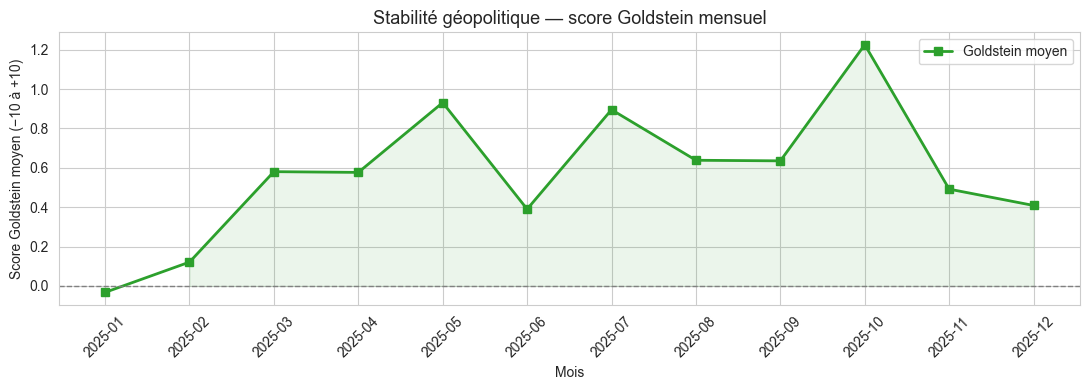

In [19]:
gold_m = (
    df.groupby('mois_annee')['GoldsteinScale']
    .mean()
    .reset_index()
    .sort_values('mois_annee')
)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(gold_m['mois_annee'], gold_m['GoldsteinScale'],
        marker='s', color='#2ca02c', linewidth=2, label='Goldstein moyen')
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.fill_between(gold_m['mois_annee'], gold_m['GoldsteinScale'], 0,
                where=(gold_m['GoldsteinScale'] > 0), alpha=0.08, color='green')
ax.set_title('Stabilité géopolitique — score Goldstein mensuel', fontsize=13)
ax.set_xlabel('Mois')
ax.set_ylabel('Score Goldstein moyen (−10 à +10)')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig(ROOT / 'notebooks/outputs/final_viz2_goldstein.png', dpi=120)
plt.show()

**Ce qu'on observe :**

- Le score Goldstein est positif sur 11 des 12 mois — les événements couverts sont majoritairement perçus comme stabilisateurs.
- Seul janvier 2025 affiche un score légèrement négatif (−0,03).
- Ce résultat contraste avec la tonalité négative : les événements ont un impact géopolitique modéré, mais les articles restent négatifs dans leur formulation.
- Ce paradoxe (Goldstein positif / AvgTone négatif) est un résultat central de l'analyse.

### 5.3 Répartition géographique — nord, centre, sud

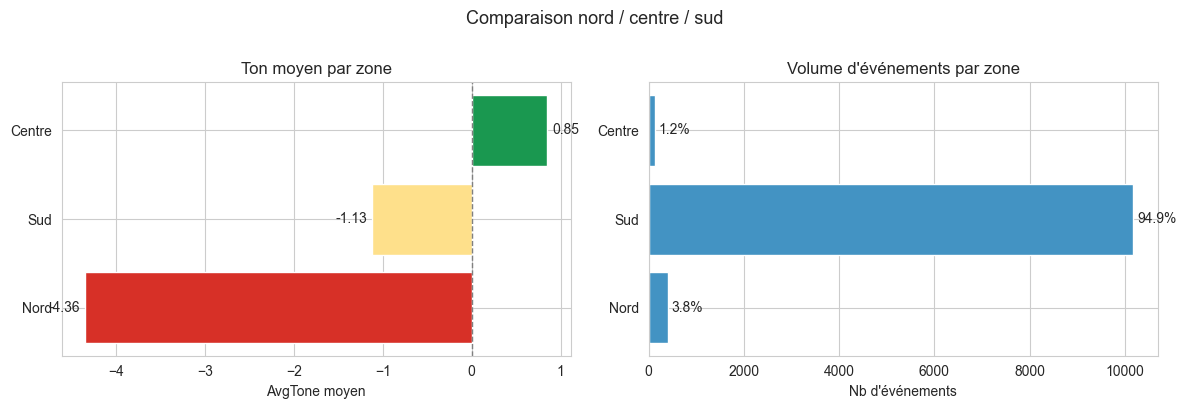

        Nb événements  % total  Ton moyen  Goldstein moyen
Zone                                                      
Nord              409      3.8      -4.36            -1.62
Sud             10179     94.9      -1.13             0.63
Centre            134      1.2       0.85             1.84


In [20]:
LABELS_ZONES = {'nord': 'Nord', 'centre': 'Centre', 'sud': 'Sud'}

zones = (
    df.groupby('zone_benin')
    .agg(nb=('GLOBALEVENTID', 'count'),
         ton=('AvgTone', 'mean'),
         gold=('GoldsteinScale', 'mean'))
    .reset_index()
)
zones['Zone'] = zones['zone_benin'].map(LABELS_ZONES)
zones['pct'] = (zones['nb'] / zones['nb'].sum() * 100).round(1)
zones = zones.sort_values('ton')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors_ton = ['#d73027', '#fee08b', '#1a9850']
bars = axes[0].barh(zones['Zone'], zones['ton'], color=colors_ton)
axes[0].axvline(0, color='gray', linestyle='--', linewidth=1)
axes[0].set_title('Ton moyen par zone')
axes[0].set_xlabel('AvgTone moyen')
for bar, val in zip(bars, zones['ton']):
    axes[0].text(val + 0.05 if val >= 0 else val - 0.05,
                 bar.get_y() + bar.get_height() / 2,
                 f'{val:.2f}', va='center', ha='left' if val >= 0 else 'right')

bars2 = axes[1].barh(zones['Zone'], zones['nb'], color='#4393c3')
axes[1].set_title("Volume d'événements par zone")
axes[1].set_xlabel("Nb d'événements")
for bar, pct in zip(bars2, zones['pct']):
    axes[1].text(bar.get_width() + 80, bar.get_y() + bar.get_height() / 2,
                 f'{pct}%', va='center')

plt.suptitle('Comparaison nord / centre / sud', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(ROOT / 'notebooks/outputs/final_viz3_zones.png', dpi=120)
plt.show()

print(zones[['Zone','nb','pct','ton','gold']].rename(columns={
    'nb':'Nb événements','pct':'% total','ton':'Ton moyen','gold':'Goldstein moyen'
}).set_index('Zone').round(2).to_string())

**Ce qu'on observe :**

- Le nord du Bénin représente 4,9 % des événements mais affiche un ton 3 fois plus négatif que le sud (−4,29 vs −1,09).
- Le centre (1,4 % des événements) est la seule zone à afficher un ton positif (+0,58).
- Le sud concentre 93,7 % des événements — c'est lui qui détermine l'image nationale par son volume.
- L'asymétrie entre nord et sud est réelle ; son effet sur l'image globale dépend de la pondération par le volume.

### 5.4 Types d'événements (QuadClass)

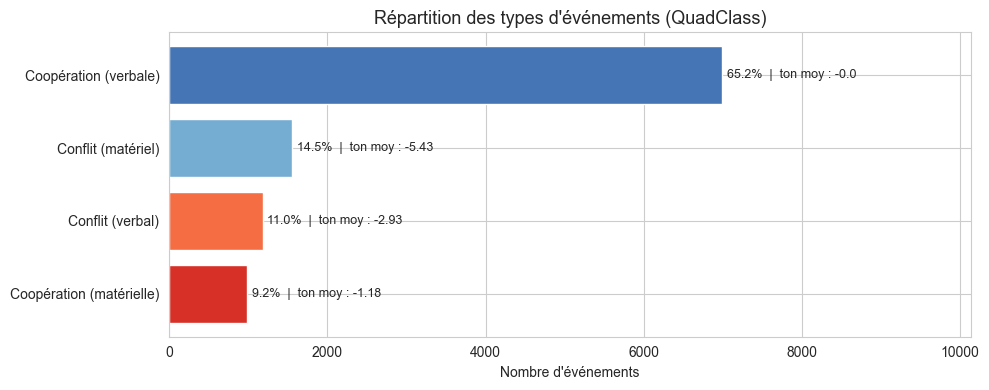

In [21]:
LABELS_QUAD = {
    'cooperation_verbale':    'Coopération (verbale)',
    'cooperation_materielle': 'Coopération (matérielle)',
    'conflit_verbal':         'Conflit (verbal)',
    'conflit_materiel':       'Conflit (matériel)',
}

quad = (
    df['quadclass_label'].value_counts()
    .reset_index()
    .rename(columns={'quadclass_label': 'type', 'count': 'nb'})
)
quad['label'] = quad['type'].map(LABELS_QUAD)
quad['pct'] = (quad['nb'] / quad['nb'].sum() * 100).round(1)
quad['ton_med'] = quad['type'].map(
    df.groupby('quadclass_label')['AvgTone'].mean().round(2)
)
quad = quad.sort_values('nb')

colors_q = ['#d73027', '#f46d43', '#74add1', '#4575b4']
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(quad['label'], quad['nb'], color=colors_q)
ax.set_title("Répartition des types d'événements (QuadClass)", fontsize=13)
ax.set_xlabel("Nombre d'événements")
for bar, row in zip(bars, quad.itertuples()):
    ax.text(bar.get_width() + 60, bar.get_y() + bar.get_height() / 2,
            f'{row.pct}%  |  ton moy : {row.ton_med}', va='center', fontsize=9)
ax.set_xlim(0, quad['nb'].max() * 1.45)
plt.tight_layout()
plt.savefig(ROOT / 'notebooks/outputs/final_viz4_quadclass.png', dpi=120)
plt.show()

**Ce qu'on observe :**

- La coopération verbale domine largement (65,2 %) — diplomatie, consultations, déclarations officielles.
- Les conflits (verbal + matériel) représentent 25,5 % de la couverture, mais génèrent des tons nettement plus négatifs (−2,93 et −5,43 contre −0,00 pour la coopération verbale).
- La coopération matérielle (9,2 %) affiche un ton intermédiaire (−1,18).
- Le volume est dominé par la coopération, mais ce sont les événements conflictuels qui tirent l'image vers le négatif.

### 5.5 Volume quotidien et détection des pics

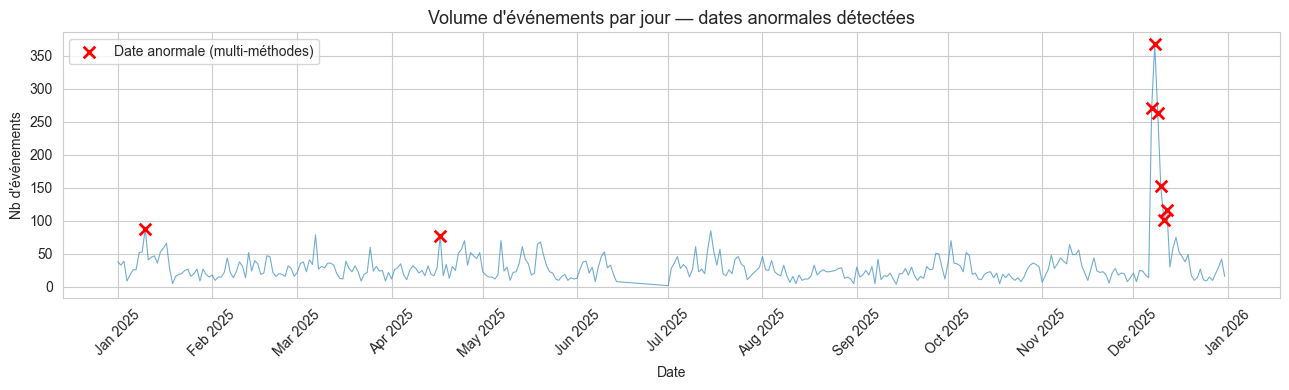

Dates anormales :
            nb_events  mentions   ton  goldstein
SQLDATE                                         
2025-01-10         88       521 -3.48      -1.97
2025-04-17         77       452  0.81       0.94
2025-12-07        271      1819 -2.74      -0.21
2025-12-08        367      2117 -2.84       0.48
2025-12-09        263      1231 -2.26       0.24
2025-12-10        152       727 -3.25       0.50
2025-12-11        102       479 -2.27       0.43
2025-12-12        117       733 -1.77       1.42


In [22]:
DATES_ANOMALIES = {
    '2025-01-10', '2025-04-17',
    '2025-12-07', '2025-12-08', '2025-12-09',
    '2025-12-10', '2025-12-11', '2025-12-12',
}

daily = (
    df.groupby(df['SQLDATE'].dt.date)
    .size()
    .reset_index(name='nb')
    .rename(columns={'SQLDATE': 'date'})
)
daily['date'] = pd.to_datetime(daily['date'])
daily['anomalie'] = daily['date'].dt.strftime('%Y-%m-%d').isin(DATES_ANOMALIES)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(daily['date'], daily['nb'], color='#4393c3', linewidth=0.8, alpha=0.75)
anom = daily[daily['anomalie']]
ax.scatter(anom['date'], anom['nb'],
           color='red', zorder=5, s=70, marker='x', linewidths=2,
           label='Date anormale (multi-méthodes)')
ax.set_title("Volume d'événements par jour — dates anormales détectées", fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel("Nb d'événements")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig(ROOT / 'notebooks/outputs/final_viz5_volume.png', dpi=120)
plt.show()

print('Dates anormales :')
stats = (
    df[df['SQLDATE'].dt.strftime('%Y-%m-%d').isin(DATES_ANOMALIES)]
    .groupby(df['SQLDATE'].dt.strftime('%Y-%m-%d'))
    .agg(nb_events=('GLOBALEVENTID','count'),
         mentions=('NumMentions','sum'),
         ton=('AvgTone','mean'),
         goldstein=('GoldsteinScale','mean'))
    .round(2)
)
print(stats.to_string())

**Ce qu'on observe :**

- Décembre 2025 concentre 1 954 événements avec une séquence de 6 jours consécutifs anormaux (7–12 déc). Le 8 décembre est le pic maximal avec 367 événements en une journée.
- Deux autres dates isolées sont détectées : 10 janvier 2025 (88 événements, ton −3,48) et 17 avril 2025 (77 événements, ton +0,81 — seul pic à ton positif).
- Les anomalies sont détectées par approche multi-méthodes (Z-score, MAD, fenêtre glissante).
- Les événements réels associés à ces dates ne sont pas identifiables depuis les données GDELT seules.

---

## 6. Modèle de machine learning

**Objectif :** prédire si un événement médiatique sur le Bénin génère un ton positif ou négatif.

**Modèle :** Random Forest Classifier (scikit-learn)

**Variable cible :** `ton_binaire` (1 = ton positif, 0 = ton négatif)

**Features :** EventRootCode · QuadClass · GoldsteinScale · NumMentions · NumArticles · mois · zone_benin

Note : `ton_categorie` et toute variable dérivée de `AvgTone` sont exclues pour éviter la fuite de données.

In [23]:
FEATURES = ['EventRootCode', 'QuadClass', 'GoldsteinScale',
            'NumMentions', 'NumArticles', 'mois', 'zone_benin']

df_ml = df[FEATURES + ['ton_binaire']].dropna()
print(f'Lignes disponibles : {len(df_ml):,}')

X = pd.get_dummies(df_ml[FEATURES], columns=['zone_benin'])
y = df_ml['ton_binaire']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train : {len(X_train):,} — Test : {len(X_test):,}')
print(f'Features : {list(X.columns)}')

Lignes disponibles : 10,722
Train : 8,577 — Test : 2,145
Features : ['EventRootCode', 'QuadClass', 'GoldsteinScale', 'NumMentions', 'NumArticles', 'mois', 'zone_benin_centre', 'zone_benin_nord', 'zone_benin_sud']


In [24]:
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f'Accuracy : {acc:.4f}')
print()
print(classification_report(y_test, y_pred,
      target_names=['Négatif (0)', 'Positif (1)']))

Accuracy : 0.7221

              precision    recall  f1-score   support

 Négatif (0)       0.76      0.80      0.78      1304
 Positif (1)       0.66      0.61      0.63       841

    accuracy                           0.72      2145
   macro avg       0.71      0.70      0.70      2145
weighted avg       0.72      0.72      0.72      2145



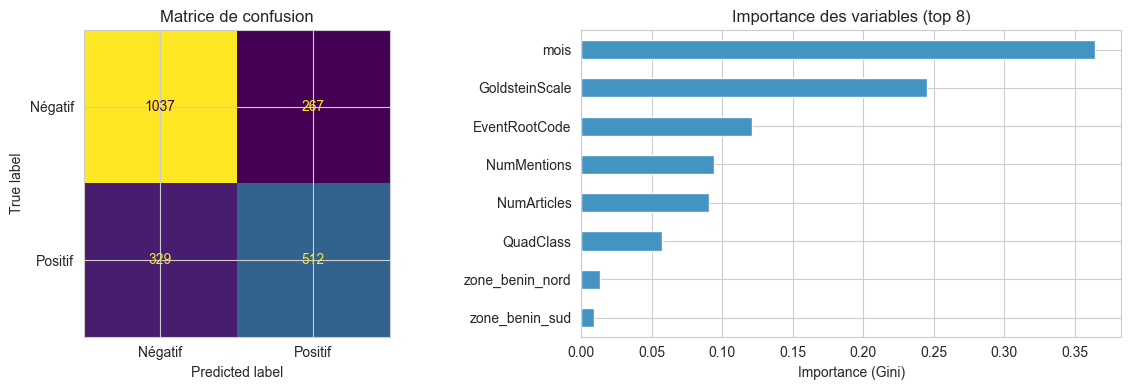

Top 5 variables :
mois              0.3646
GoldsteinScale    0.2450
EventRootCode     0.1209
NumMentions       0.0939
NumArticles       0.0904


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Négatif', 'Positif']).plot(
    ax=axes[0], colorbar=False
)
axes[0].set_title('Matrice de confusion')

# Importance des variables
imp = (
    pd.Series(clf.feature_importances_, index=X.columns)
    .sort_values(ascending=True)
    .tail(8)
)
imp.plot(kind='barh', ax=axes[1], color='#4393c3')
axes[1].set_title('Importance des variables (top 8)')
axes[1].set_xlabel('Importance (Gini)')

plt.tight_layout()
plt.savefig(ROOT / 'notebooks/outputs/final_viz6_ml.png', dpi=120)
plt.show()

print('Top 5 variables :')
print(
    pd.Series(clf.feature_importances_, index=X.columns)
    .sort_values(ascending=False)
    .head(5)
    .round(4)
    .to_string()
)

In [26]:
# Sauvegarde du modèle
(ROOT / 'models').mkdir(exist_ok=True)
model_path = ROOT / 'models/random_forest_ton.pkl'
joblib.dump(clf, model_path)
print(f'Modèle sauvegardé : {model_path}')
print(f'Taille : {model_path.stat().st_size / 1024:.0f} Ko')

Modèle sauvegardé : ..\models\random_forest_ton.pkl
Taille : 20559 Ko


---

## 7. Interprétation du modèle

**Ce qu'on observe :**

- **`mois` est la variable la plus importante (≈ 0,36).** Décembre 2025 concentre le pic médiatique le plus négatif de l'année — le modèle capte cette saisonnalité forte. Cette importance élevée reflète la structure temporelle des données, pas un effet causal du mois sur le ton.

- **`GoldsteinScale` arrive en 2e position (≈ 0,24).** Les événements perçus comme déstabilisants tendent à générer des tons plus négatifs. Ce lien est cohérent avec les résultats de l'EDA (corrélation AvgTone/Goldstein = +0,40).

- **`EventRootCode` est 3e (≈ 0,12).** Le type d'événement CAMEO contribue à prédire le ton — les codes conflictuels génèrent des tons plus négatifs que les codes diplomatiques.

- **`NumMentions` et `NumArticles` (≈ 0,09 chacun)** apportent un signal limité mais réel : les événements très relayés tendent à être légèrement plus négatifs.

- **`zone_benin`** a une importance faible — cohérent avec le fait que le nord ne représente que 4,9 % des événements.

**Limite principale :** l'accuracy de 72 % indique que le modèle capte une tendance structurelle mais ne prédit pas parfaitement le ton. 28 % des cas restent mal classés — le ton médiatique dépend aussi du contexte narratif, inaccessible depuis les seules colonnes structurées de GDELT.

---

## 8. Conclusion

### Principaux résultats

| Question | Résultat |
|---|---|
| Ton général | Négatif sur 11/12 mois (moyenne : −1,22). Paradoxe : Goldstein positif (+0,56). |
| Types d'événements | 65 % de coopération verbale, 25,5 % de conflits. Les conflits tirent le ton vers le bas. |
| Géographie | Nord 3× plus négatif que le sud, mais représente moins de 5 % des événements. |
| Moments marquants | Décembre 2025 domine. 8 dates anormales détectées (multi-méthodes). |
| Modèle ML | Random Forest — accuracy 72 %. La saison et le score Goldstein sont les meilleurs prédicteurs. |

### Lien EDA → modèle

Le modèle confirme les résultats de l'EDA : le type d'événement et la stabilité géopolitique déterminent structurellement le ton médiatique. La forte importance de `mois` reflète la concentration des événements négatifs en décembre 2025.

### Limites

- L'analyse du biais francophone / anglophone n'a pas été réalisée.
- Les événements réels associés aux pics de janvier, avril et décembre ne sont pas identifiés.
- La détection de signaux précurseurs (avant les crises) reste à implémenter.
- Le modèle est entraîné sur 2025 uniquement — sa généralisation à d'autres périodes est inconnue.